In [ ]:
import pandas as pd
import numpy as np
import json
import networkx as nx


In [81]:
path_data = "/home/mccf3797/Documents/workspace/graphgenerator/data/wd-movies/train_split.tsv"

In [169]:
# read tsv file
# we read the json file line by line
movies_list = []

with open(path_data, "r") as f:
    
    movie_tmp = {"actors" : [], "genres" : []}
    idx = 0
    
    for line in f:
        
        triplet = line.split("\t")
        
        if len(triplet) == 1:
            movies_list.append(movie_tmp)
            movie_tmp = {"actors" : [], "genres" : []}
            idx += 1
            continue
        
        if "has_director" == triplet[1]:
            movie_tmp["director"] = triplet[2].strip()
            movie_tmp["idx"] = idx
            
            
        if "has_actor" == triplet[1]:
            movie_tmp["actors"].append(triplet[2].strip())
            
        if "has_genre" == triplet[1]:
            movie_tmp["genres"].append(triplet[2].strip())




In [170]:
# retrieve the list of person (actors and director)
list_persons = []

for element in movies_list:
    list_persons += element["actors"] + [element["director"]]
    
set_person = list(set(list_persons))

# create the mapper between this set and an int value
dict_person = dict(zip(set_person, range(len(movies_list), len(movies_list) + len(set_person))))


In [171]:
nodes_movies = pd.DataFrame({"id": range(len(movies_list))})
nodes_movies["labels_int"] = 0

In [172]:
node_persons = pd.DataFrame({"id": range(len(movies_list), len(movies_list) + len(set_person))})
node_persons["labels_int"] = 1

In [173]:
# concat the two elements
nodes_df = pd.concat([nodes_movies, node_persons])

In [174]:
edges_list_element = []

# creating the edges list
for element in movies_list:
    # create the director and the actors list triplet
    source = element["idx"]
    
    for target_name in element["actors"]:
        edges_list_element.append([source, 0, dict_person[target_name]])
        
    edges_list_element.append([source, 1, dict_person[element["director"]]])

edges_df = pd.DataFrame(edges_list_element, columns=["source", "labels_int", "target"])


In [175]:
path = "/home/mccf3797/Documents/workspace/graphgenerator/data_kg/wd-movies/"
edges_df.to_parquet(path + "edges.parquet")
nodes_df.to_parquet(path + "nodes.parquet")

In [190]:
edges_df

,source,labels_int,target
0,0,0,38309
1,0,0,61530
2,0,0,56937
3,0,0,61194
4,0,0,45144
...,...,...,...
192810,38265,0,55392
192811,38265,1,60815
192812,38266,0,52555
192813,38266,0,60367


In [176]:
nodes_df[nodes_df["id"] == 1000]

,id,labels_int
1000,1000,0


In [177]:
movies_list[1000]

{'actors': ['Pran', 'Hema Malini', 'Bob Christo', 'Amitabh Bachchan'],
 'genres': [],
 'director': 'Pramod Chakravorty',
 'idx': 1000}

In [178]:
# make it non directed
G = nx.Graph()

# add the nodes to the graph
for index, row in nodes_df.iterrows():
    G.add_node(int(row["id"]), label=row["labels_int"])

# add the edges to the graph
for index, row in edges_df.iterrows():
    G.add_edge(int(row["source"]), int(row["target"]), label=row["labels_int"])
    
G = G.to_undirected()

In [186]:
import heapq  # For the priority queue
from collections import Counter  # Useful for efficiently counting


def sampling_local_subgraph_optimized(G, start_node, nb_nodes_to_sample):
    """
    Sample a local subgraph from the graph G starting from start_node.
    The subgraph is sampled using a greedy expansion strategy (adding node
    with most connections to the current subgraph).
    The subgraph is sampled until it reaches the target size or until no more nodes can be added.
    The subgraph is returned as a new graph.

    Optimized for performance using a priority queue.
    """
    if start_node not in G:
        raise ValueError(f"Start node {start_node} not found in graph G.")
    if nb_nodes_to_sample <= 0:
        return G.subgraph(
            []
        ).copy()  # Return empty graph if 0 or negative nodes requested
    if nb_nodes_to_sample == 1:
        return G.subgraph([start_node]).copy()

    # 1. Initialize
    subgraph_nodes = {start_node}  # Use a set for efficient O(1) lookups and additions

    # Stores counts of connections from candidate nodes to the current subgraph
    # Key: node, Value: number of connections
    candidate_counts = Counter()

    # Priority queue to efficiently get the node with max connections
    # Stores tuples: (-count, node) to simulate a max-heap using Python's min-heap (heapq)
    priority_queue = []  # Will store (negative_count, node)

    # 2. Seed the candidates with neighbors of the start_node
    # O(degree(start_node) * log(degree(start_node)))
    for neighbor in G.neighbors(start_node):
        # A neighbor cannot be the start_node if self-loops exist and we don't want it in subgraph
        # until explicitly chosen. However, if start_node is the only node, it's already in.
        # This check is more robust for general cases.
        if neighbor not in subgraph_nodes:
            candidate_counts[neighbor] += 1
            # Push to heap: (-count, node). Negative count means highest count is smallest in heap.
            heapq.heappush(priority_queue, (-candidate_counts[neighbor], neighbor))

    # 3. Greedy Expansion Loop
    # Runs up to nb_nodes_to_sample-1 times (as start_node is already in)
    # Each iteration: O(log(N_candidates) + d_avg * log(N_candidates))
    while len(subgraph_nodes) < nb_nodes_to_sample:
        next_node_to_add = None

        # Efficiently find the best candidate node from the priority queue
        # This loop handles stale entries in the priority queue.
        while priority_queue:
            current_priority, node = heapq.heappop(priority_queue)
            current_count = -current_priority  # Convert back to positive count

            # Check if this node is still a valid candidate (not already in subgraph)
            # and if its count in the PQ is still the most up-to-date count from candidate_counts.
            if node not in subgraph_nodes and candidate_counts[node] == current_count:
                next_node_to_add = node
                break
            # Else, this is a stale entry in the priority queue (either 'node' was already added
            # to subgraph_nodes, or its count was updated and a newer entry was pushed).
            # Just discard it and continue to the next best.

        if next_node_to_add is None:
            # No more valid candidates to add. This can happen if the current subgraph
            # forms a connected component smaller than target_size, or becomes isolated.
            print(
                f"Warning: Could only find {len(subgraph_nodes)} nodes using greedy expansion."
            )
            print(
                "The component might be smaller than the target size or became isolated."
            )
            break

        subgraph_nodes.add(next_node_to_add)

        # Update candidate counts for neighbors of the newly added node
        # and push them to the priority queue
        # O(degree(next_node_to_add) * log(N_candidates))
        for neighbor in G.neighbors(next_node_to_add):
            if neighbor not in subgraph_nodes:
                candidate_counts[neighbor] += 1
                # Push the updated count to the priority queue.
                # This might create duplicate entries for the same node in the PQ,
                # but the `while priority_queue` loop above efficiently handles them.
                heapq.heappush(priority_queue, (-candidate_counts[neighbor], neighbor))

    # 4. Create the subgraph
    # G.subgraph() returns a SubGraphView. Use .copy() for an independent graph.
    # This step's complexity depends on the number of nodes/edges in the resulting subgraph.
    final_nodes_list = list(subgraph_nodes)
    subgraph = G.subgraph(final_nodes_list).copy()

    return subgraph


start_node = 3000
nb_nodes_to_sample = 64


subgraph = sampling_local_subgraph_optimized(G, start_node, 100)

In [187]:
subgraph.nodes()

NodeView((24074, 43535, 39452, 12837, 14381, 46137, 15933, 11329, 38470, 6727, 50761, 12362, 47690, 13900, 1109, 27737, 4187, 1633, 1644, 18541, 3698, 51832, 7289, 7802, 637, 638, 4225, 4234, 1675, 50830, 4240, 9366, 1689, 3738, 55964, 3746, 1699, 4269, 26286, 39600, 42161, 41654, 1729, 40652, 6862, 1755, 52971, 43244, 44283, 1794, 1798, 42759, 53514, 4877, 39695, 45330, 11547, 40227, 1839, 10547, 1845, 10550, 4411, 49980, 10558, 1856, 14145, 46913, 47441, 4950, 4438, 3933, 2399, 48999, 59243, 1392, 43920, 23952, 39828, 60822, 41880, 42392, 40865, 21411, 2472, 45992, 14760, 8109, 5041, 53171, 3000, 8137, 1487, 54751, 1508, 6129, 1522, 13812, 8184, 24060))

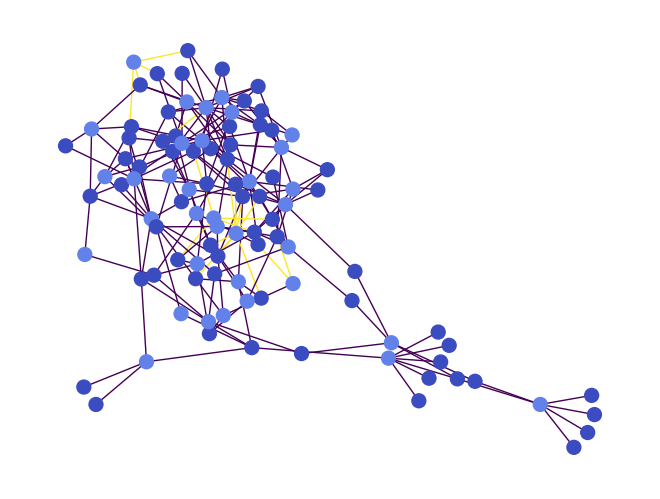

In [188]:
import matplotlib.pyplot as plt

nodes_label = nx.get_node_attributes(subgraph, "label")
nodes_label = [nodes_label[key] for key in nodes_label]

edges_label = nx.get_edge_attributes(subgraph, "label")
edges_label = [edges_label[key] for key in edges_label]

nx.draw(subgraph, node_size=100, font_size=10, with_labels=False,
                node_color=nodes_label,
                edge_color=edges_label,
                cmap=plt.cm.coolwarm,vmin=0,vmax=8)

In [26]:
subgraph.nodes

NodeView((24576, 1026, 4112, 1043, 1058, 23606, 574, 575, 579, 36932, 1093, 583, 585, 589, 590, 591, 596, 9813, 599, 601, 602, 603, 1116, 1115, 1120, 610, 17509, 617, 35949, 623, 1139, 632, 634, 637, 1152, 115333, 35975, 1159, 651, 1164, 657, 659, 665, 670, 1187, 676, 20136, 685, 14005, 697, 707, 709, 6857, 715, 719, 726, 734, 737, 741, 7912, 7914, 7916, 753, 762, 3843, 772, 774, 779, 783, 7444, 7453, 7455, 800, 7460, 819, 7483, 18257, 856, 22365, 23405, 7049, 905, 910, 911, 7057, 919, 9632, 12714, 12731, 34757, 84430, 35286, 23009, 30182, 1001, 1007, 1011, 1013, 1017, 1022))

In [19]:
subgraph.edges(data=True)

EdgeDataView([(24576, 1022, {'label': 4}), (24576, 1017, {'label': 4}), (24576, 1139, {'label': 4}), (24576, 20136, {'label': 7}), (24576, 12731, {'label': 7}), (24576, 9632, {'label': 7}), (24576, 30182, {'label': 7}), (24576, 9813, {'label': 7}), (24576, 23405, {'label': 7}), (24576, 14005, {'label': 7}), (24576, 17509, {'label': 7}), (24576, 22365, {'label': 7}), (1026, 6857, {'label': 0}), (1026, 7057, {'label': 1}), (1026, 7460, {'label': 2}), (1026, 12731, {'label': 4}), (1026, 20136, {'label': 4}), (1026, 23009, {'label': 4}), (4112, 7453, {'label': 2}), (4112, 34757, {'label': 6}), (4112, 35949, {'label': 6}), (4112, 35975, {'label': 6}), (1043, 6857, {'label': 0}), (1043, 7049, {'label': 1}), (1043, 7455, {'label': 2}), (1043, 35949, {'label': 6}), (1043, 34757, {'label': 6}), (1043, 35286, {'label': 6}), (1058, 6857, {'label': 0}), (1058, 7057, {'label': 1}), (1058, 7444, {'label': 2}), (23606, 919, {'label': 4}), (23606, 905, {'label': 4}), (23606, 726, {'label': 4}), (23606